In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Change this path if needed
WORKBOOK = Path("221953930-219431865.xlsx")

# Output folder
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Load sheets
stock_profile = pd.read_excel(WORKBOOK, sheet_name="Stock_Profile")
stock_day = pd.read_excel(WORKBOOK, sheet_name="Stock_Day")
intraday = pd.read_excel(WORKBOOK, sheet_name="Intraday_Bars")

# Convert dates/times
stock_day["session_date"] = pd.to_datetime(stock_day["session_date"])
intraday["session_date"] = pd.to_datetime(intraday["session_date"])
intraday["bar_start_utc"] = pd.to_datetime(intraday["bar_start_utc"])

print("Stock_Profile:", stock_profile.shape)
print("Stock_Day:", stock_day.shape)
print("Intraday_Bars:", intraday.shape)

Stock_Profile: (59, 10)
Stock_Day: (1180, 11)
Intraday_Bars: (92026, 12)


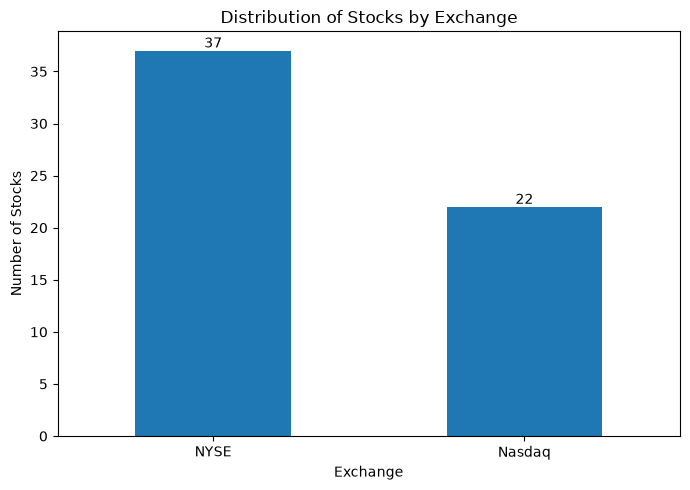

In [2]:
exchange_counts = stock_profile["exchange"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

exchange_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribution of Stocks by Exchange")
ax.set_xlabel("Exchange")
ax.set_ylabel("Number of Stocks")
ax.tick_params(axis="x", rotation=0)

# Add counts above bars
for i, value in enumerate(exchange_counts):
    ax.text(i, value + 0.3, str(value), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure1_exchange_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

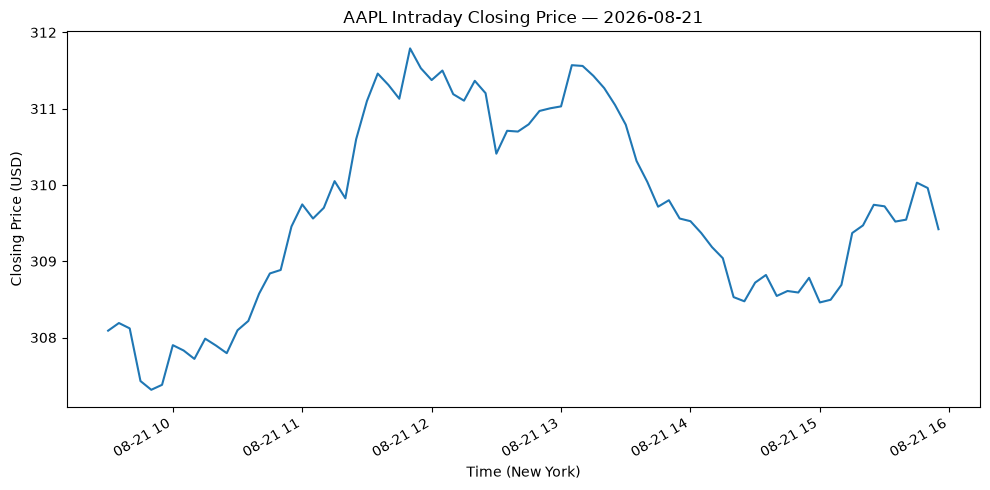

In [3]:
TICKER = "AAPL"

available_dates = (
    intraday.loc[intraday["ticker"] == TICKER, "session_date"]
    .drop_duplicates()
    .sort_values()
)

DATE = available_dates.iloc[0]

sample = intraday[
    (intraday["ticker"] == TICKER) &
    (intraday["session_date"] == DATE)
].sort_values("bar_start_utc").copy()

# Convert UTC to New York time for easier interpretation
times = sample["bar_start_utc"]

if times.dt.tz is None:
    times = times.dt.tz_localize("UTC")

sample["time_ny"] = times.dt.tz_convert("America/New_York")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sample["time_ny"], sample["close"])

ax.set_title(f"{TICKER} Intraday Closing Price — {DATE.date()}")
ax.set_xlabel("Time (New York)")
ax.set_ylabel("Closing Price (USD)")

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure2_intraday_price.png",
            dpi=300, bbox_inches="tight")
plt.show()

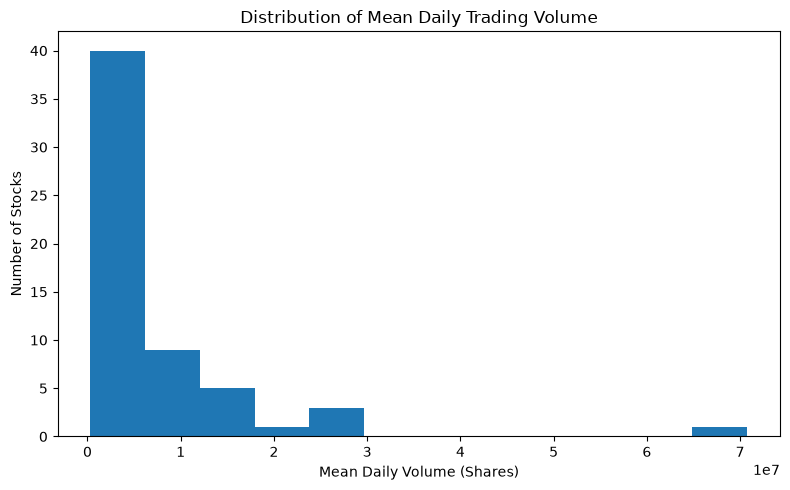

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(stock_profile["mean_daily_volume"].dropna(), bins=12)

ax.set_title("Distribution of Mean Daily Trading Volume")
ax.set_xlabel("Mean Daily Volume (Shares)")
ax.set_ylabel("Number of Stocks")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure3_mean_daily_volume_histogram.png",
            dpi=300, bbox_inches="tight")
plt.show()

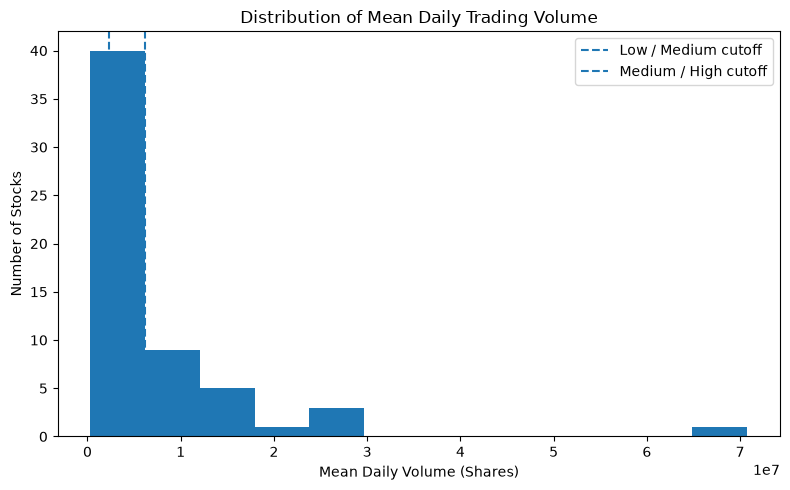

In [5]:
LOW_CUTOFF = 2298919.133333333
HIGH_CUTOFF = 6147448.6

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(stock_profile["mean_daily_volume"].dropna(), bins=12)

ax.axvline(LOW_CUTOFF, linestyle="--", label="Low / Medium cutoff")
ax.axvline(HIGH_CUTOFF, linestyle="--", label="Medium / High cutoff")

ax.set_title("Distribution of Mean Daily Trading Volume")
ax.set_xlabel("Mean Daily Volume (Shares)")
ax.set_ylabel("Number of Stocks")
ax.legend()

plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure3_mean_daily_volume_histogram.png",
            dpi=300, bbox_inches="tight")
plt.show()

C:\Users\diego_xwgyocr\AppData\Local\Temp\ipykernel_31592\2780489265.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


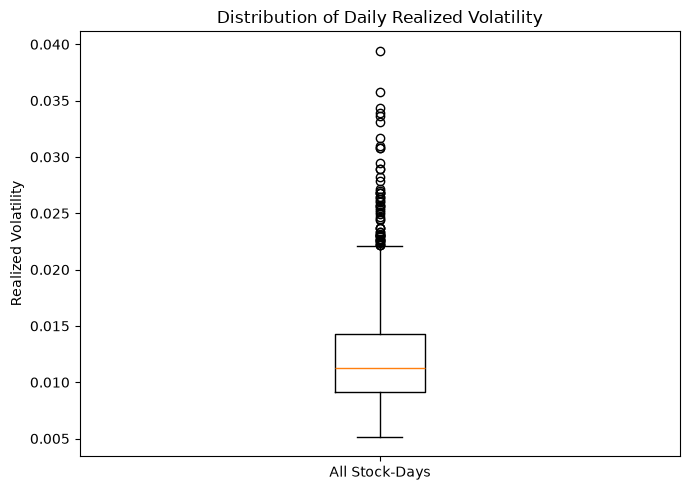

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    stock_day["realized_volatility"].dropna(),
    vert=True
)

ax.set_title("Distribution of Daily Realized Volatility")
ax.set_ylabel("Realized Volatility")
ax.set_xticks([1])
ax.set_xticklabels(["All Stock-Days"])

plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure4_realized_volatility_boxplot.png",
            dpi=300, bbox_inches="tight")
plt.show()

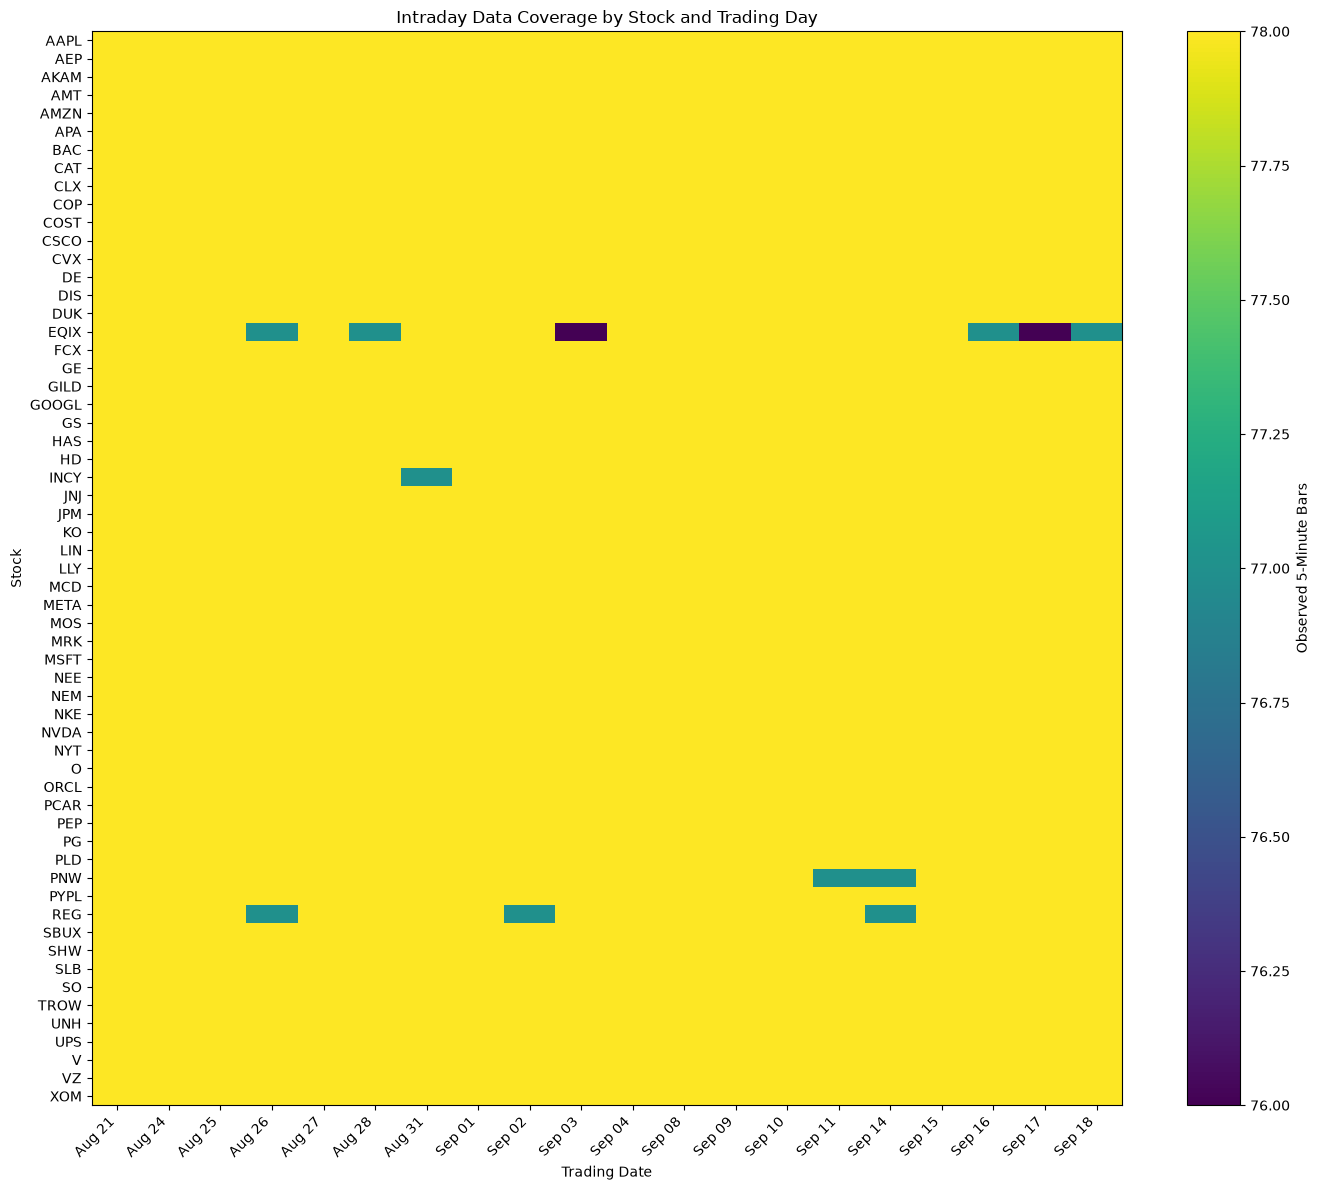

In [7]:
coverage = (
    intraday
    .groupby(["ticker", "session_date"])
    .size()
    .unstack(fill_value=0)
)

# Sort stocks alphabetically and dates chronologically
coverage = coverage.sort_index()
coverage = coverage.reindex(sorted(coverage.columns), axis=1)

fig, ax = plt.subplots(figsize=(14, 12))

image = ax.imshow(
    coverage.values,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title("Intraday Data Coverage by Stock and Trading Day")
ax.set_xlabel("Trading Date")
ax.set_ylabel("Stock")

# X-axis dates
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(
    [d.strftime("%b %d") for d in coverage.columns],
    rotation=45,
    ha="right"
)

# Y-axis tickers
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Observed 5-Minute Bars")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure5_coverage_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [8]:
print("Exchange counts:")
print(stock_profile["exchange"].value_counts())

print("\nLiquidity tiers:")
print(stock_profile["liquidity_tier"].value_counts())

print("\nVolatility tiers:")
print(stock_day["volatility_tier"].value_counts())

print("\nCoverage distribution:")
print(
    intraday
    .groupby(["ticker", "session_date"])
    .size()
    .value_counts()
    .sort_index()
)

print("\nMean daily volume summary:")
print(stock_profile["mean_daily_volume"].describe())

print("\nRealized volatility summary:")
print(stock_day["realized_volatility"].describe())

Exchange counts:
exchange
NYSE      37
Nasdaq    22
Name: count, dtype: int64

Liquidity tiers:
liquidity_tier
High      20
Low       20
Medium    19
Name: count, dtype: int64

Volatility tiers:
volatility_tier
Low       424
High      388
Medium    368
Name: count, dtype: int64

Coverage distribution:
76       2
77      10
78    1168
Name: count, dtype: int64

Mean daily volume summary:
count    5.900000e+01
mean     7.490869e+06
std      1.076707e+07
min      3.197304e+05
25%      1.820622e+06
50%      3.900987e+06
75%      9.556874e+06
max      7.075744e+07
Name: mean_daily_volume, dtype: float64

Realized volatility summary:
count    1180.000000
mean        0.012420
std         0.004699
min         0.005170
25%         0.009095
50%         0.011268
75%         0.014304
max         0.039436
Name: realized_volatility, dtype: float64
